# RegimeRadar — Phase 1: Exploratory Data Analysis

**Goal:** understand the statistical character of the data *before* modeling, and confirm the
stylized facts of financial volatility that justify the whole project (regimes, vol forecasting).

This notebook predicts **nothing** — it only *describes*. We look for:

1. **Volatility clustering** — large moves follow large moves (the core premise).
2. **Fat tails** — returns are far from Gaussian; extreme days are common.
3. **Autocorrelation structure** — returns are ~unpredictable, but *squared/abs* returns are highly
   autocorrelated (volatility is forecastable — this is what we model).
4. **VIX as a forward-looking vol gauge** vs realized vol.
5. **Drawdowns & crisis episodes** — the regimes we later detect should line up with these.

Figures are saved to `reports/figures/` for the dashboard and report.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titleweight"] = "bold"

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252  # annualization factor

def savefig(name):
    """Save current figure to reports/figures/ at dashboard-friendly DPI."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

print("ROOT:", ROOT)
print("figures ->", FIG_DIR)

ROOT: D:\regime-radar
figures -> D:\regime-radar\reports\figures


In [2]:
# Load the Phase-0 aligned dataset
df = pd.read_csv(ROOT / "data" / "processed" / "dataset.csv", index_col=0, parse_dates=True)
df.index.name = "date"

print(df.shape)
print(df.index.min().date(), "->", df.index.max().date())
df.head()

(5909, 11)
2003-01-03 -> 2026-06-30


,spy_open,spy_high,spy_low,spy_close,spy_volume,vix_close,tnx_close,fedfunds,cpiaucsl,unrate,t10y2y
date,,,,,,,,,,,
2003-01-03,59.224757,59.530941,58.957653,59.511398,32222600,24.680000,4.038,NaN,NaN,NaN,2.27
2003-01-06,59.439761,60.905560,59.394159,60.560284,40984500,24.910000,4.066,1.24,NaN,NaN,2.26
2003-01-07,60.521206,60.827396,60.065176,60.410458,38640400,25.129999,4.025,1.24,NaN,NaN,2.25
2003-01-08,60.065135,60.195431,59.315953,59.537449,38702200,25.530001,3.981,1.24,NaN,NaN,2.27
2003-01-09,59.817586,60.703580,59.550488,60.462536,34804900,24.250000,4.148,1.24,NaN,NaN,2.29


In [3]:
# Returns and realized volatility (these are descriptive, not features yet)
ret = np.log(df["spy_close"]).diff()              # daily log returns
df["ret"] = ret
df["ret_pct"] = df["spy_close"].pct_change() * 100

# Realized vol = rolling std of daily returns, annualized
df["rv_21"] = ret.rolling(21).std() * np.sqrt(TRADING_DAYS) * 100   # ~1 month
df["rv_63"] = ret.rolling(63).std() * np.sqrt(TRADING_DAYS) * 100   # ~1 quarter

summary = df["ret_pct"].describe()
print("Daily return %% summary:\n", summary.round(3))
print(f"\nAnnualized vol (full sample): {df['ret'].std() * np.sqrt(TRADING_DAYS) * 100:.1f}%")
print(f"Skew    : {stats.skew(ret.dropna()):.3f}")
print(f"Kurtosis (excess): {stats.kurtosis(ret.dropna()):.3f}  (Gaussian = 0)")

Daily return %% summary:
 count    5908.000
mean        0.050
std         1.171
min       -10.942
25%        -0.397
50%         0.075
75%         0.581
max        14.520
Name: ret_pct, dtype: float64

Annualized vol (full sample): 18.6%
Skew    : -0.302
Kurtosis (excess): 14.628  (Gaussian = 0)


## 1. Price history & drawdowns

The cumulative drawdown curve marks every crisis episode. We expect the regime detector (Phase 3)
to flag high-volatility states right where these drawdowns plunge.

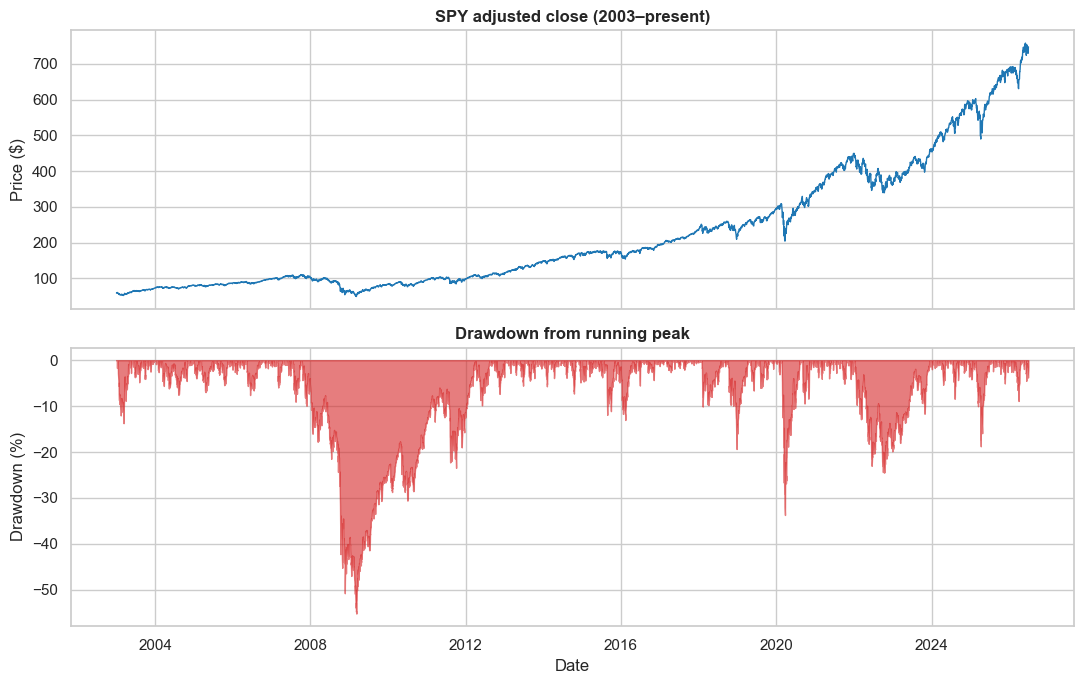

Max drawdown: -55.2% on 2009-03-09


In [4]:
cum_max = df["spy_close"].cummax()
drawdown = (df["spy_close"] / cum_max - 1.0) * 100

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(df.index, df["spy_close"], lw=1, color="#1f77b4")
axes[0].set_title("SPY adjusted close (2003–present)")
axes[0].set_ylabel("Price ($)")

axes[1].fill_between(df.index, drawdown, 0, color="#d62728", alpha=0.6)
axes[1].set_title("Drawdown from running peak")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
savefig("01_price_drawdown")
plt.show()

worst = drawdown.nsmallest(1)
print(f"Max drawdown: {worst.iloc[0]:.1f}% on {worst.index[0].date()}")

## 2. Volatility clustering

The single most important stylized fact for this project: turbulent days cluster together, and so do
calm days. If returns were i.i.d. this plot would look like uniform noise — it does not.

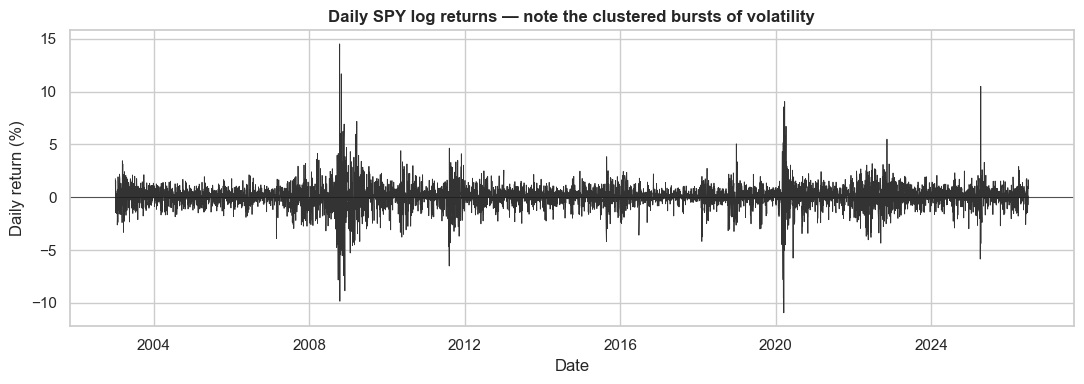

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df["ret_pct"], lw=0.6, color="#333333")
ax.set_title("Daily SPY log returns — note the clustered bursts of volatility")
ax.set_ylabel("Daily return (%)")
ax.set_xlabel("Date")
ax.axhline(0, color="k", lw=0.5)
savefig("02_returns_clustering")
plt.show()

## 3. Fat tails — returns are not Gaussian

A histogram against a fitted normal and a Q–Q plot. The tails fanning away from the diagonal in the
Q–Q plot are the visual signature of fat tails (high excess kurtosis), which is why we forecast
*intervals with calibrated coverage* (Phase 6) rather than trusting Gaussian error bars.

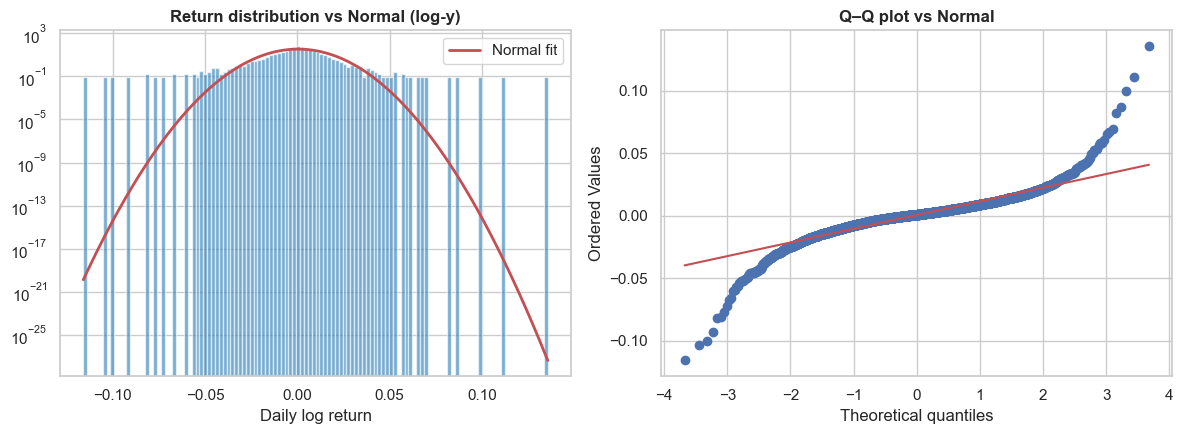

Jarque–Bera: stat=52,767, p=0  (p<<0.05 => reject normality)


In [6]:
r = ret.dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram vs fitted normal
axes[0].hist(r, bins=120, density=True, alpha=0.6, color="#1f77b4")
x = np.linspace(r.min(), r.max(), 400)
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r-", lw=2, label="Normal fit")
axes[0].set_yscale("log")  # log-y exposes the fat tails
axes[0].set_title("Return distribution vs Normal (log-y)")
axes[0].set_xlabel("Daily log return")
axes[0].legend()

# Q-Q plot
stats.probplot(r, dist="norm", plot=axes[1])
axes[1].set_title("Q–Q plot vs Normal")
savefig("03_fat_tails")
plt.show()

jb_stat, jb_p = stats.jarque_bera(r)
print(f"Jarque–Bera: stat={jb_stat:,.0f}, p={jb_p:.3g}  (p<<0.05 => reject normality)")

## 4. Autocorrelation: returns vs squared returns

**Returns** show almost no autocorrelation (markets are ~efficient — we deliberately do *not* predict
direction). But **squared / absolute returns** are strongly and persistently autocorrelated. That
persistence is *volatility memory* — the thing this project actually forecasts.

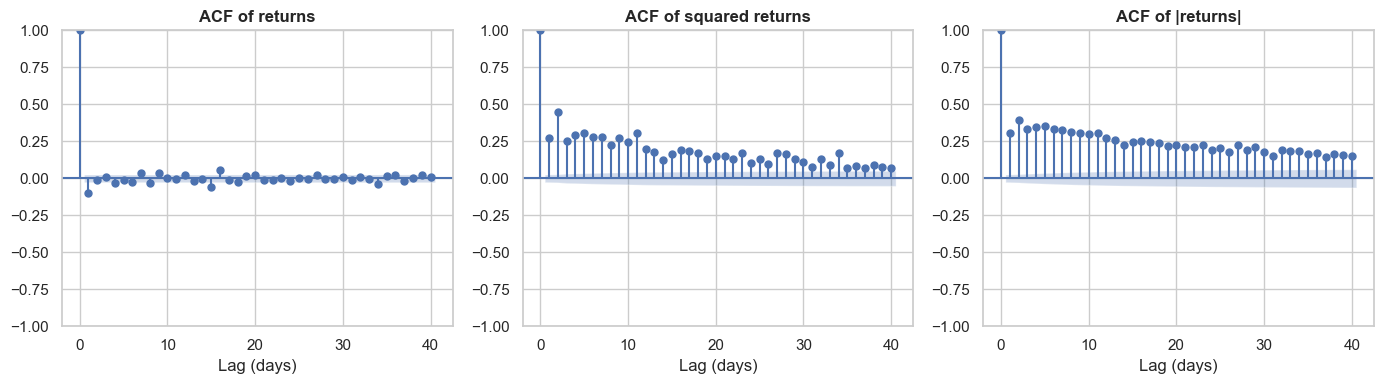

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_acf(r, lags=40, ax=axes[0], title="ACF of returns")
plot_acf(r**2, lags=40, ax=axes[1], title="ACF of squared returns")
plot_acf(r.abs(), lags=40, ax=axes[2], title="ACF of |returns|")
for a in axes:
    a.set_xlabel("Lag (days)")
savefig("04_acf_vol_memory")
plt.show()

## 5. VIX vs realized volatility

VIX is the market's *forward-looking* 30-day implied vol. Plotting it against trailing realized vol
shows VIX leading/tracking turbulence, and the (mostly positive) gap = the volatility risk premium.

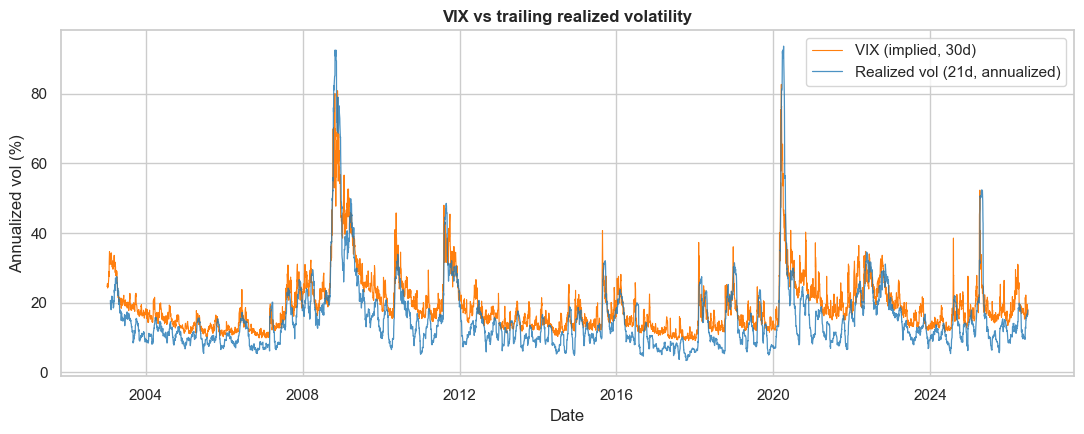

corr(VIX, realized vol 21d) = 0.870


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df.index, df["vix_close"], lw=0.8, color="#ff7f0e", label="VIX (implied, 30d)")
ax.plot(df.index, df["rv_21"], lw=0.9, color="#1f77b4", alpha=0.8, label="Realized vol (21d, annualized)")
ax.set_title("VIX vs trailing realized volatility")
ax.set_ylabel("Annualized vol (%)")
ax.set_xlabel("Date")
ax.legend()
savefig("05_vix_vs_realized")
plt.show()

corr = df[["vix_close", "rv_21"]].dropna().corr().iloc[0, 1]
print(f"corr(VIX, realized vol 21d) = {corr:.3f}")

## 6. Correlation snapshot of all features

A quick look at how market and macro series co-move — useful context before feature engineering.

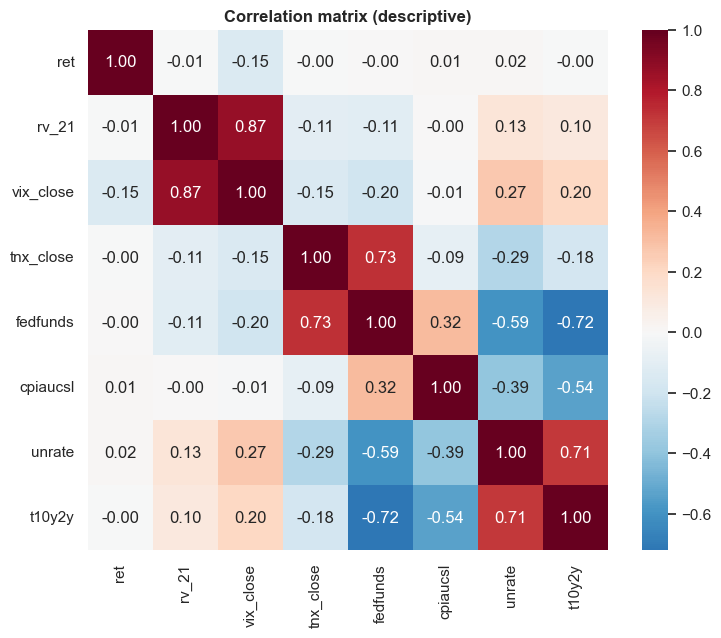

In [9]:
cols = ["ret", "rv_21", "vix_close", "tnx_close", "fedfunds", "cpiaucsl", "unrate", "t10y2y"]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix (descriptive)")
savefig("06_correlation_matrix")
plt.show()

## Takeaways → next phases

- **Vol clustering + autocorrelated squared returns** confirm volatility is forecastable → motivates
  the lagged-vol features in **Phase 2** and the models in **Phases 4–5**.
- **Fat tails / non-normality** mean point forecasts are not enough → motivates calibrated intervals
  in **Phase 6**.
- **Drawdown episodes** give us ground-truth turbulent periods to sanity-check the **Phase 3** regimes.
- **VIX tracks realized vol** strongly → a valuable feature and a forecasting benchmark.

All figures saved under `reports/figures/`.